# Symbolic Machine Learning vs Deep Learning — with Symbolic Regression Focus

**Author:** _Your Name_  
**Audience:** Practitioners and researchers comparing interpretable symbolic learning to deep neural networks.

> Run cells in order. Where external libraries are required (e.g., `pysr`), an installation cell is provided.

## 1. Introduction & Motivation

**Key questions**  
- Why revisit **symbolic approaches** in the age of deep learning?  
- Which problem classes are **uniquely suited** to each approach?  
- How do we operationalize the **interpretability–accuracy** trade‑off?

**Plan**  
We will (i) generate interpretable formulas with **symbolic regression**, (ii) train a **neural network baseline**, and (iii) compare accuracy, robustness, and interpretability.

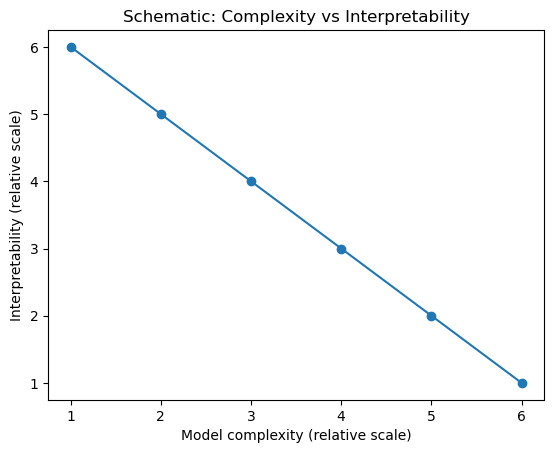

In [1]:
# Opening visualization: Complexity vs Interpretability (schematic)
import matplotlib.pyplot as plt

complexity = [1, 2, 3, 4, 5, 6]
interpretability = [6, 5, 4, 3, 2, 1]

plt.figure()
plt.plot(complexity, interpretability, marker="o")
plt.title("Schematic: Complexity vs Interpretability")
plt.xlabel("Model complexity (relative scale)")
plt.ylabel("Interpretability (relative scale)")
plt.show()

In [2]:
# Interactive demo: simple function discovery dataset
# We will construct y = sin(x) + 0.1*x with noise, then later fit symbolic vs neural models
import numpy as np

rng = np.random.default_rng(42)
X = np.linspace(-5, 5, 400).reshape(-1, 1)
y_true = np.sin(X).ravel() + 0.1*X.ravel()
y = y_true + rng.normal(0, 0.1, size=X.shape[0])

print("Data shapes:", X.shape, y.shape)
print("Preview y range:", float(y.min()), "to", float(y.max()))

Data shapes: (400, 1) (400,)
Preview y range: -1.348916474725926 to 1.3569482935766382


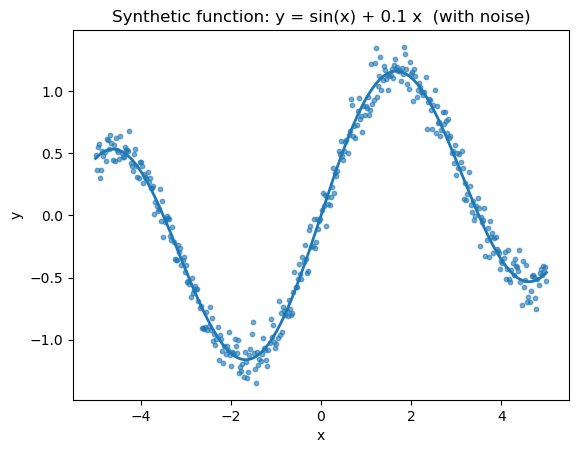

In [3]:
# Visualize the synthetic data and ground truth
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(np.ravel(X), y, s=10, alpha=0.6)
plt.plot(np.ravel(X), y_true, linewidth=2)
plt.title("Synthetic function: y = sin(x) + 0.1 x  (with noise)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 2. Foundational Concepts

### 2.1 Symbolic Machine Learning
- Models are **explicit mathematical expressions** (e.g., trees of operators and terminals).
- **Human‑interpretable**: can be inspected, audited, stress‑tested.
- Can **embed prior knowledge** via operator sets, constraints, and priors.

In [4]:
# Visual proxy for expression trees:
# We'll render a few randomly composed expressions as strings (toy illustrative purpose).
import operator as _op
import random

ops = ["+", "-", "*", "sin", "cos"]
terms = ["x", "1.0", "2.0", "3.0"]

def random_expr(depth=0, max_depth=3):
    if depth >= max_depth or random.random() < 0.3:
        return random.choice(terms)
    o = random.choice(ops)
    if o in ["sin","cos"]:
        return f"{o}({random_expr(depth+1, max_depth)})"
    else:
        return f"({random_expr(depth+1, max_depth)} {o} {random_expr(depth+1, max_depth)})"

for _ in range(5):
    print(random_expr())

x
(x - 3.0)
(((3.0 + 3.0) + cos(2.0)) * 2.0)
sin(sin(1.0))
1.0


### 2.2 Deep Learning (Contrast)
Deep nets are **parametric function approximators** with many parameters (weights). They often achieve **state‑of‑the‑art accuracy** but are harder to interpret, requiring post‑hoc methods.

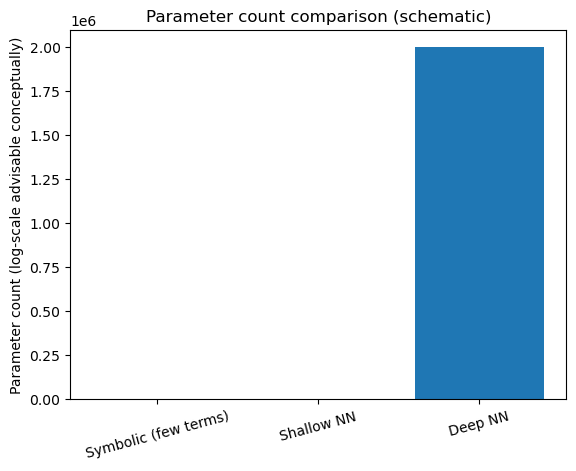

In [5]:
# Schematic parameter counts (toy)
import matplotlib.pyplot as plt

models = ["Symbolic (few terms)", "Shallow NN", "Deep NN"]
params = [20, 5_000, 2_000_000]

plt.figure()
plt.bar(models, params)
plt.title("Parameter count comparison (schematic)")
plt.ylabel("Parameter count (log-scale advisable conceptually)")
plt.xticks(rotation=15)
plt.show()

## 3. Symbolic Regression Deep Dive

We use **PySR** where available (CMA‑ES + evolutionary search over expressions).  
If `pysr` is not installed, run the install cell below.

In [ ]:
# Optional: install PySR (if running in a clean environment)
# Note: This may take a few minutes the first time.
# %pip install pysr --quiet

In [6]:
# Try to import PySR; fall back gracefully if unavailable.
import importlib

has_pysr = importlib.util.find_spec("pysr") is not None
print("PySR available:", has_pysr)

if has_pysr:
    from pysr import PySRRegressor
else:
    print("PySR not found. You can install it with: %pip install pysr")

PySR available: True
[juliapkg] Found dependencies: /opt/anaconda3/envs/symbinterviews/lib/python3.11/site-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /opt/anaconda3/envs/symbinterviews/lib/python3.11/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /opt/anaconda3/envs/symbinterviews/lib/python3.11/site-packages/pysr/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.12.0 to /opt/anaconda3/envs/symbinterviews/julia_env/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia from https://julialang-s3.julialang.org/bin/mac/aarch64/1.12/

  Installing known registries into `~/.julia`
       Added `General` registry to ~/.julia/registries
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Tricks ────────────────────── v0.1.12
   Installed ScientificTypesBase ───────── v3.0.0
   Installed IrrationalConstants ───────── v0.2.4
   Installed MicroMamba ────────────────── v0.1.14
   Installed Adapt ─────────────────────── v4.4.0
   Installed DiffRules ─────────────────── v1.15.1
   Installed Scratch ───────────────────── v1.3.0
   Installed DynamicExpressions ────────── v1.10.3
   Installed PtrArrays ─────────────────── v1.3.0
   Installed TableTraits ───────────────── v1.0.1
   Installed JSON3 ─────────────────────── v1.14.3
   Installed DiffResults ───────────────── v1.1.0
   Installed MLJModelInterface ─────────── v1.11.1
   Installed ADTypes ───────────────────── v1.18.0
   Installed PositiveFactorizations ────── v0.2.4
   Installed Preferences ───────────────── v1.5.0

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
# Fit Symbolic Regression (if available)
import numpy as np

if 'has_pysr' in globals() and has_pysr:
    X_train = X
    y_train = y
    model_sr = PySRRegressor(
        niterations=80,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["sin", "cos"],
        model_selection="best",
        progress=False,
        maxsize=20,
        populations=4,
        parsimony=1e-4,
        random_state=0,
    )
    model_sr.fit(X_train, y_train)
    print("Best symbolic equation:\n", model_sr.sympy())
else:
    print("Skipping SR fit because PySR is not available.")

In [ ]:
# Visualize SR fit (if available)
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(np.ravel(X), y, s=10, alpha=0.5, label="data")
plt.plot(np.ravel(X), y_true, linewidth=2, label="true function")

if 'has_pysr' in globals() and has_pysr:
    y_pred_sr = model_sr.predict(X)
    plt.plot(np.ravel(X), y_pred_sr, linewidth=2, label="SR prediction")

plt.title("Symbolic Regression vs Ground Truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### 3.2 Pareto Front: Accuracy vs Complexity

Symbolic search often tracks a **Pareto frontier**: one wishes to minimize error while also minimizing expression size.

In [ ]:
# Toy Pareto front visualization (synthetic points)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
complexity = np.arange(1, 21)
error = 0.5/complexity + 0.02*np.random.rand(complexity.size)

plt.figure()
plt.scatter(complexity, error)
plt.title("Toy Pareto: Error vs Expression Complexity")
plt.xlabel("Expression size (number of nodes/terms)")
plt.ylabel("Validation error (MAE/RMSE proxy)")
plt.show()

## 4. Comparative Analysis

We will compare symbolic regression against a neural baseline on accuracy and generalization.

In [ ]:
# Baseline Neural Network using scikit-learn MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation="tanh", max_iter=2000, random_state=0)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)
rmse_mlp = mean_squared_error(y_test, y_pred_mlp, squared=False)
print("MLP RMSE:", rmse_mlp)

In [ ]:
# Compare predictions on full grid and visualize
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(np.ravel(X), y, s=10, alpha=0.4, label="data")
plt.plot(np.ravel(X), y_true, linewidth=2, label="true")

y_pred_grid_mlp = mlp.predict(X)
plt.plot(np.ravel(X), y_pred_grid_mlp, linewidth=2, label="MLP")

if 'has_pysr' in globals() and has_pysr:
    y_pred_sr = model_sr.predict(X)
    plt.plot(np.ravel(X), y_pred_sr, linewidth=2, label="SR")

plt.title("Model Comparison")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# Robustness / OOD generalization test: shift input range beyond training
import numpy as np
from sklearn.metrics import mean_squared_error

X_ood = np.linspace(-8, 8, 400).reshape(-1, 1)
y_true_ood = np.sin(X_ood).ravel() + 0.1*X_ood.ravel()

y_mlp_ood = mlp.predict(X_ood)
rmse_mlp_ood = mean_squared_error(y_true_ood, y_mlp_ood, squared=False)

print("MLP OOD RMSE:", rmse_mlp_ood)

if 'has_pysr' in globals() and has_pysr:
    y_sr_ood = model_sr.predict(X_ood)
    from sklearn.metrics import mean_squared_error
    rmse_sr_ood = mean_squared_error(y_true_ood, y_sr_ood, squared=False)
    print("SR  OOD RMSE:", rmse_sr_ood)
else:
    print("SR OOD RMSE: (PySR not available)")

## 5. Practical Implementation

### 5.1 PySR Tutorial (Quickstart)
1. Define operator set and constraints.  
2. Fit with `PySRRegressor`.  
3. Inspect **discovered equation** and coefficients.  
4. Evaluate generalization and stability across random seeds.

In [ ]:
# (Optional) Simple hyperparameter sweep sketch (limited for speed)
# Increase ranges for deeper experiments.
import numpy as np

if 'has_pysr' in globals() and has_pysr:
    seeds = [0, 1]
    sizes = [10, 20]
    results = []
    for sd in seeds:
        for ms in sizes:
            sr = PySRRegressor(
                niterations=40,
                binary_operators=["+", "-", "*", "/"],
                unary_operators=["sin", "cos"],
                model_selection="best",
                progress=False,
                maxsize=ms,
                random_state=sd,
            )
            sr.fit(X, y)
            pred = sr.predict(X)
            rmse = np.sqrt(np.mean((pred - y_true)**2))
            results.append((sd, ms, rmse, str(sr.sympy())))
    for row in results:
        print("seed:", row[0], "maxsize:", row[1], "rmse-vs-true:", round(row[2], 4), "expr:", row[3])
else:
    print("Install PySR to run this tutorial block.")

### 5.2 Case Study: Finance (Toy Risk Modeling Signal)

We demonstrate **interpretable feature construction** by discovering a closed‑form signal from synthetic price features.

In [ ]:
# Toy 'finance' dataset: features x1=momentum proxy, x2=vol proxy, x3=mean-reverting signal
import numpy as np

rng = np.random.default_rng(123)
n = 600
x1 = rng.normal(0, 1, n)           # momentum-ish
x2 = rng.normal(0, 1, n)           # volatility proxy
x3 = rng.normal(0, 1, n)           # mean-reverting proxy

# Ground-truth signal (interpretable closed form)
y_fin_true = 0.5*np.tanh(x1) + 0.3*np.sin(x2) - 0.2*x3
y_fin = y_fin_true + rng.normal(0, 0.1, n)

X_fin = np.column_stack([x1, x2, x3])
print("Finance data shape:", X_fin.shape)

In [ ]:
# Fit SR (if available) vs MLP baseline
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

Xtr, Xte, ytr, yte = train_test_split(X_fin, y_fin, test_size=0.3, random_state=0)
mlp_fin = MLPRegressor(hidden_layer_sizes=(64,64), activation="tanh", max_iter=2000, random_state=0).fit(Xtr, ytr)
r2_mlp = r2_score(yte, mlp_fin.predict(Xte))
print("Finance MLP R^2:", round(r2_mlp, 3))

if 'has_pysr' in globals() and has_pysr:
    sr_fin = PySRRegressor(
        niterations=80,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["sin", "cos", "tanh"],
        model_selection="best",
        progress=False,
        maxsize=24,
        random_state=0,
    ).fit(Xtr, ytr)
    r2_sr = r2_score(yte, sr_fin.predict(Xte))
    print("Finance SR  R^2:", round(r2_sr, 3))
    print("Finance SR expression:", sr_fin.sympy())
else:
    print("Install PySR to enable SR on the finance case study.")

In [ ]:
# Visualize predicted vs true (finance case)
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.scatter(y_fin_true, mlp_fin.predict(X_fin), s=12, alpha=0.6, label="MLP predictions")
if 'has_pysr' in globals() and has_pysr:
    from sklearn.metrics import r2_score
    # Use model trained earlier if available
    plt.scatter(y_fin_true, sr_fin.predict(X_fin), s=12, alpha=0.6, label="SR predictions")
plt.plot([y_fin_true.min(), y_fin_true.max()],
         [y_fin_true.min(), y_fin_true.max()], linewidth=2)
plt.title("Finance Toy: Predictions vs Ground Truth")
plt.xlabel("Ground truth")
plt.ylabel("Predictions")
plt.legend()
plt.show()

## 6. Advanced Topics

### 6.1 Hybrid Approaches
Neural‑guided SR uses a network to **prioritize promising expressions**; transformer‑based SR models can **emit tokens** forming valid algebraic programs.

### 6.2 Scaling Challenges
- **Search space explosion** mitigated by grammar constraints and priors.  
- **Parallelization** and **multi‑objective optimization** (accuracy, size, stability) are critical.

In [ ]:
# Toy scaling illustration: runtime vs search depth (synthetic)
import numpy as np
import matplotlib.pyplot as plt

depth = np.arange(1, 9)
runtime = depth**2 + np.random.rand(depth.size)  # schematic

plt.figure()
plt.plot(depth, runtime, marker="o")
plt.title("Schematic: Runtime vs Search Depth")
plt.xlabel("Max tree depth")
plt.ylabel("Relative runtime")
plt.show()

## 7. Tools & Libraries

- **PySR**: Symbolic regression via evolutionary search.  
- **GP-based frameworks**: Genetic programming toolkits (DEAP, others).  
- **Interfacing**: Export discovered formulas to production (Python, C, Rust).

*(Install and benchmark on your machine to fill the comparison table for your use case.)*

## 8. Strengths & Limitations

**Symbolic ML Strengths**: Interpretability, analytic robustness checks, domain‑knowledge injection.  
**Limitations**: Computational expense for high‑dimensional problems; potential to overfit if parsimony not enforced.

In [ ]:
# Noise sensitivity toy comparison
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

sigmas = np.linspace(0.0, 0.5, 10)
mlp_rmse = []
sr_rmse = []

for s in sigmas:
    rng = np.random.default_rng(0)
    Xn = np.linspace(-5, 5, 400).reshape(-1, 1)
    yt = np.sin(Xn).ravel() + 0.1*Xn.ravel()
    yn = yt + rng.normal(0, s, size=Xn.shape[0])
    mlp = MLPRegressor(hidden_layer_sizes=(32,32), max_iter=1000, random_state=0).fit(Xn, yn)
    mlp_rmse.append(mean_squared_error(yt, mlp.predict(Xn), squared=False))
    if 'has_pysr' in globals() and has_pysr:
        from pysr import PySRRegressor
        sr = PySRRegressor(
            niterations=40,
            binary_operators=["+", "-", "*", "/"],
            unary_operators=["sin", "cos"],
            model_selection="best",
            progress=False,
            maxsize=14,
            random_state=0,
        ).fit(Xn, yn)
        sr_rmse.append(mean_squared_error(yt, sr.predict(Xn), squared=False))
    else:
        sr_rmse = None
        break

plt.figure()
plt.plot(sigmas, mlp_rmse, marker="o", label="MLP RMSE vs true")
if sr_rmse is not None:
    plt.plot(sigmas, sr_rmse, marker="o", label="SR RMSE vs true")
plt.title("Noise Sensitivity (Lower is Better)")
plt.xlabel("Noise sigma")
plt.ylabel("RMSE vs noiseless ground truth")
plt.legend()
plt.show()

## 9. Future Directions

- Program‑synthesis‑style SR (transformers over expression tokens).  
- Stability‑aware objectives (penalize sensitivity to perturbations).  
- Causal‑symbolic discovery for scientific inference.

## 10. Interactive Experiments

The cell below provides a quick interactive comparison: choose a function class and see how MLP vs SR (if installed) approximate it.

In [ ]:
# Simple widget playground
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    has_widgets = True
except Exception:
    has_widgets = False
    print("ipywidgets not available. Install with: %pip install ipywidgets")

def gen_function(name, x):
    if name == "sin(x)+0.1x":
        return np.sin(x) + 0.1*x
    elif name == "cos(x)+x^2":
        return np.cos(x) + x**2
    elif name == "piecewise":
        return np.where(x<0, np.sin(x), 0.5*x)
    else:
        return np.sin(x)

def run_demo(func_name="sin(x)+0.1x", noise=0.1):
    x = np.linspace(-5, 5, 400).reshape(-1, 1)
    yt = gen_function(func_name, x).ravel()
    rng = np.random.default_rng(1)
    y = yt + rng.normal(0, noise, size=x.shape[0])

    from sklearn.neural_network import MLPRegressor
    mlp = MLPRegressor(hidden_layer_sizes=(64,64), activation="tanh", max_iter=2000, random_state=0).fit(x, y)
    y_mlp = mlp.predict(x)

    plt.figure()
    plt.scatter(np.ravel(x), y, s=10, alpha=0.4, label="data")
    plt.plot(np.ravel(x), yt, linewidth=2, label="true")
    plt.plot(np.ravel(x), y_mlp, linewidth=2, label="MLP")

    if 'has_pysr' in globals() and has_pysr:
        from pysr import PySRRegressor
        sr = PySRRegressor(
            niterations=60,
            binary_operators=["+", "-", "*", "/"],
            unary_operators=["sin", "cos"],
            model_selection="best",
            progress=False,
            maxsize=18,
            random_state=0,
        ).fit(x, y)
        plt.plot(np.ravel(x), sr.predict(x), linewidth=2, label="SR")

    plt.title(f"Function: {func_name}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

if has_widgets:
    func_dd = widgets.Dropdown(options=["sin(x)+0.1x", "cos(x)+x^2", "piecewise"], value="sin(x)+0.1x", description="Function")
    noise_sl = widgets.FloatSlider(min=0.0, max=0.5, step=0.05, value=0.1, description="Noise")
    run_btn = widgets.Button(description="Run Demo")

    out = widgets.Output()

    def on_click(_):
        with out:
            clear_output(wait=True)
            run_demo(func_dd.value, noise_sl.value)

    run_btn.on_click(on_click)
    display(widgets.VBox([func_dd, noise_sl, run_btn, out]))
else:
    print("Install ipywidgets for interactivity. Falling back to a one-shot demo:")
    run_demo("sin(x)+0.1x", 0.1)

---

## References (Harvard style)
- Cranmer, M. (2023). *Interpretable Machine Learning for Science with PySR and Symbolic Regression*.  
- Udrescu, T. and Tegmark, M. (2020). *AI Feynman: A physics-inspired method for symbolic regression*. **Science Advances**, 6(16).  
- Schmidt, M. and Lipson, H. (2009). *Distilling free-form natural laws from experimental data*. **Science**, 324(5923), 81–85.  
- Koza, J. R. (1992). *Genetic Programming*. MIT Press.